Talle 5 - Reducción de Dimensiones y Clustering con Spotify


In [1]:
# librerias que voy a usar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


No tenia un csv de spotify a la mano, entonces me inventé unos datos parecidos a canciones reales (con 5 tipos de musica distintos) para poder probar el codigo. Si uno tiene el csv real solo hay que cargarlo aqui en vez de esto.


In [2]:
import os

DATA_PATH = "/mnt/user-data/uploads/spotify_tracks.csv"

def hacer_datos_falsos(seed=42):
    # invento canciones parecidas a 5 tipos de musica, cada una con numeritos
    # de energia, baile, acustico, etc, para poder practicar el clustering
    rng = np.random.default_rng(seed)

    def grupo(n, medias, desv, nombre):
        datos = {}
        for f in medias:
            valores = rng.normal(medias[f], desv[f], n)
            if f == "loudness":
                # el volumen si puede ser negativo (en spotify va de -60 a 0)
                valores = np.clip(valores, -60, 0)
            else:
                # las demas caracteristicas no deben ser negativas
                valores = np.clip(valores, 0, None)
            datos[f] = valores
        d = pd.DataFrame(datos)
        d["genero"] = nombre
        return d

    edm = grupo(220,
        dict(danceability=0.82, energy=0.90, loudness=-4.0, speechiness=0.07, acousticness=0.02,
             instrumentalness=0.35, liveness=0.18, valence=0.60, tempo=126, duration_ms=210000),
        dict(danceability=0.04, energy=0.03, loudness=1.0, speechiness=0.02, acousticness=0.02,
             instrumentalness=0.12, liveness=0.05, valence=0.10, tempo=4, duration_ms=15000),
        "electronica")

    acustico = grupo(200,
        dict(danceability=0.40, energy=0.22, loudness=-13.0, speechiness=0.035, acousticness=0.88,
             instrumentalness=0.02, liveness=0.12, valence=0.35, tempo=92, duration_ms=230000),
        dict(danceability=0.05, energy=0.05, loudness=1.5, speechiness=0.015, acousticness=0.06,
             instrumentalness=0.03, liveness=0.04, valence=0.10, tempo=10, duration_ms=25000),
        "acustico")

    rap = grupo(210,
        dict(danceability=0.80, energy=0.62, loudness=-6.5, speechiness=0.32, acousticness=0.06,
             instrumentalness=0.0, liveness=0.16, valence=0.50, tempo=98, duration_ms=195000),
        dict(danceability=0.05, energy=0.06, loudness=1.2, speechiness=0.06, acousticness=0.03,
             instrumentalness=0.01, liveness=0.05, valence=0.12, tempo=8, duration_ms=18000),
        "rap")

    clasica = grupo(150,
        dict(danceability=0.20, energy=0.12, loudness=-20.0, speechiness=0.035, acousticness=0.97,
             instrumentalness=0.90, liveness=0.14, valence=0.25, tempo=86, duration_ms=280000),
        dict(danceability=0.04, energy=0.04, loudness=2.0, speechiness=0.015, acousticness=0.02,
             instrumentalness=0.06, liveness=0.05, valence=0.10, tempo=12, duration_ms=40000),
        "clasica")

    rock = grupo(200,
        dict(danceability=0.50, energy=0.85, loudness=-5.0, speechiness=0.045, acousticness=0.05,
             instrumentalness=0.10, liveness=0.24, valence=0.55, tempo=120, duration_ms=240000),
        dict(danceability=0.05, energy=0.04, loudness=1.0, speechiness=0.015, acousticness=0.03,
             instrumentalness=0.06, liveness=0.06, valence=0.12, tempo=10, duration_ms=20000),
        "rock")

    df_ = pd.concat([edm, acustico, rap, clasica, rock], ignore_index=True)
    for c in ["valence", "danceability", "energy", "acousticness", "instrumentalness",
              "liveness", "speechiness"]:
        df_[c] = df_[c].clip(0, 1)

    df_ = df_.sample(frac=1, random_state=seed).reset_index(drop=True)
    df_.insert(0, "id_cancion", [f"cancion_{i}" for i in range(len(df_))])
    return df_

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("cargue el csv real:", df.shape)
else:
    df = hacer_datos_falsos()
    print("no encontre un csv, entonces use datos inventados:", df.shape)

df.head()


no encontre un csv, entonces use datos inventados: (980, 12)


,id_cancion,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,genero
0,cancion_0,0.505717,0.842545,-5.916235,0.060132,0.039639,0.121056,0.087981,0.158408,135.182689,271399.563922,rock
1,cancion_1,0.881149,0.616811,-4.676570,0.300719,0.028547,0.008725,0.193531,0.717352,98.411183,190074.929015,rap
2,cancion_2,0.936554,0.895574,-3.636546,0.070778,0.032394,0.536226,0.197866,0.571940,121.697056,221588.097114,electronica
3,cancion_3,0.186143,0.061778,-20.529544,0.035663,0.976006,0.893115,0.161059,0.117843,68.502433,233714.854056,clasica
4,cancion_4,0.806051,0.907912,-1.579585,0.075652,0.026717,0.644891,0.242438,0.650808,129.442119,219906.638498,electronica


In [3]:
# reviso que no falte nada
print(df.shape)
print(df.isna().sum())
print("repetidas:", df.duplicated(subset=["id_cancion"]).sum())

columnas = ["danceability", "energy", "loudness", "speechiness", "acousticness",
            "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
columnas = [c for c in columnas if c in df.columns]

df[columnas].describe()


(980, 12)
id_cancion          0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
genero              0
dtype: int64
repetidas: 0


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000
mean,0.570532,0.573728,-9.081139,0.104207,0.356802,0.241257,0.170558,0.458821,104.999489,227409.881829
std,0.233690,0.314510,5.837155,0.113390,0.421915,0.317602,0.064897,0.166814,17.950361,34898.128145
min,0.093096,0.006630,-25.412675,0.000000,0.000000,0.000000,0.000000,0.000000,54.340663,146995.485395
25%,0.398274,0.224037,-13.180549,0.035350,0.032380,0.007843,0.124676,0.335670,90.703823,202978.670108
50%,0.528685,0.646508,-6.411351,0.052556,0.067667,0.078421,0.167086,0.468801,103.921473,221540.561893
75%,0.802878,0.872541,-4.648841,0.088283,0.887317,0.358488,0.206751,0.579420,121.708319,248493.638083
max,0.963551,1.000000,-1.402326,0.449208,1.000000,1.000000,0.446156,0.938019,147.019679,382065.330932


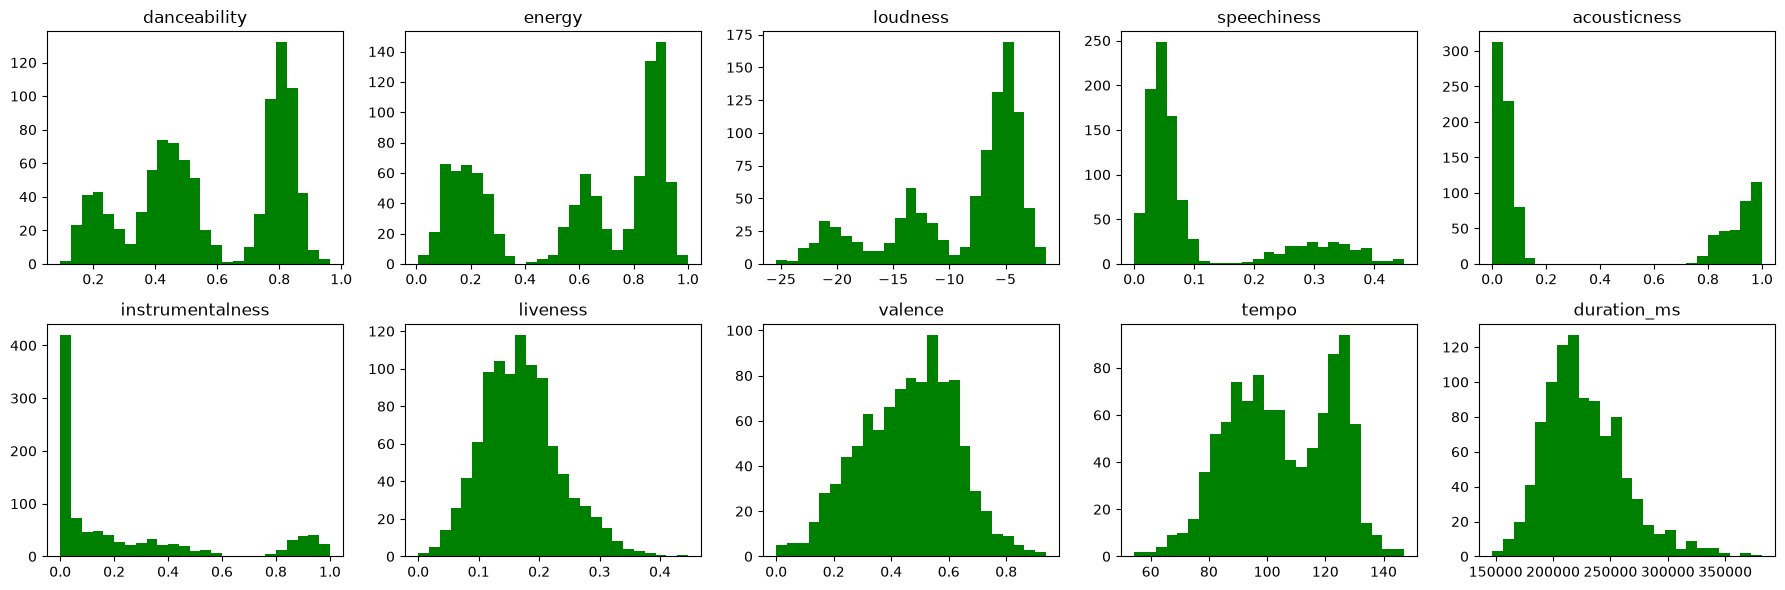

In [4]:
# le echo un ojo a como se ven las columnas
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()
for i, c in enumerate(columnas):
    axes[i].hist(df[c], bins=25, color="green")
    axes[i].set_title(c)
plt.tight_layout()
plt.show()


Antes de agrupar toca dejar todos los numeros en una escala parecida. Si no, la duración le va a ganar a todo lo demas y va a dañar el agrupamiento. Por eso escalo todo con StandardScaler.


In [5]:
# quito repetidos y filas vacias
df2 = df.drop_duplicates(subset=["id_cancion"]).dropna(subset=columnas).reset_index(drop=True)

X = df2[columnas].values

# dejo todo en la misma escala
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)


Con 10 columnas es dificil dibujar o agrupar bien, entonces uso PCA para resumir la info en menos numeros. Le dije que me deje suficientes para explicar el 90% de la info, y salieron 5.


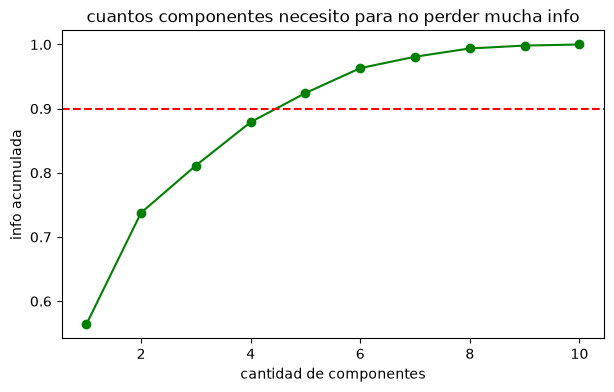

con 5 componentes ya me quedo con el 90% de la info


In [6]:
# miro cuanta info se guarda con cada componente
pca_todo = PCA(random_state=42).fit(X_esc)
var_acum = np.cumsum(pca_todo.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(var_acum)+1), var_acum, marker="o", color="green")
plt.axhline(0.90, color="red", linestyle="--")
plt.xlabel("cantidad de componentes")
plt.ylabel("info acumulada")
plt.title("cuantos componentes necesito para no perder mucha info")
plt.show()

n_comp = int(np.argmax(var_acum >= 0.90) + 1)
print("con", n_comp, "componentes ya me quedo con el 90% de la info")


In [7]:
# me quedo con los componentes que me sirven para agrupar
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_esc)

# y otros 3 solo para poder dibujar bonito despues
pca_dibujo = PCA(n_components=3, random_state=42)
X_dibujo = pca_dibujo.fit_transform(X_esc)
df2["pc1"], df2["pc2"], df2["pc3"] = X_dibujo[:,0], X_dibujo[:,1], X_dibujo[:,2]


Ahora toca decidir en cuantos grupos separar las canciones. Para eso probé varios numeros de grupos y miré dos cosas: el "codo" y el "silhouette". Con eso elegí 5 grupos, porque separaba bien la musica electronica del rock, que es algo que tiene sentido para armar listas de reproduccion distintas.


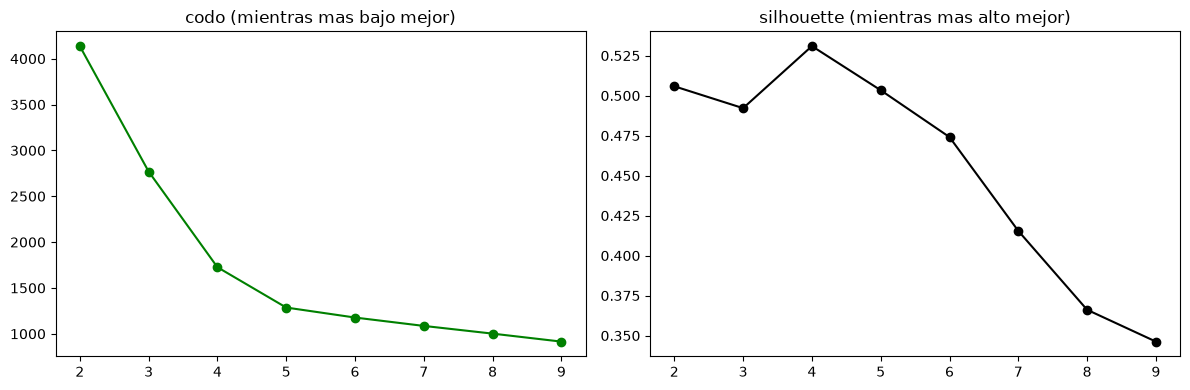

k = 2 -> puntaje 0.506
k = 3 -> puntaje 0.492
k = 4 -> puntaje 0.531
k = 5 -> puntaje 0.503
k = 6 -> puntaje 0.474
k = 7 -> puntaje 0.415
k = 8 -> puntaje 0.366
k = 9 -> puntaje 0.346


In [8]:
# pruebo con distintas cantidades de grupos
posibles_k = range(2, 10)
inercias = []
puntajes = []

for k in posibles_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_pca)
    inercias.append(modelo.inertia_)
    puntajes.append(silhouette_score(X_pca, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(posibles_k), inercias, marker="o", color="green")
axes[0].set_title("codo (mientras mas bajo mejor)")
axes[1].plot(list(posibles_k), puntajes, marker="o", color="black")
axes[1].set_title("silhouette (mientras mas alto mejor)")
plt.tight_layout()
plt.show()

for k, p in zip(posibles_k, puntajes):
    print("k =", k, "-> puntaje", round(p,3))


In [9]:
# me quedo con 5 grupos
k_final = 5
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df2["grupo_kmeans"] = kmeans.fit_predict(X_pca)

print("que tan bien quedaron separados:", round(silhouette_score(X_pca, df2["grupo_kmeans"]), 3))
print(df2["grupo_kmeans"].value_counts())


que tan bien quedaron separados: 0.503
grupo_kmeans
0    222
3    210
2    200
4    198
1    150
Name: count, dtype: int64


Ahora pruebo otra forma de agrupar que se llama DBSCAN. Esta no le dice de antemano cuantos grupos quiere, sino que junta lo que esta muy pegado y deja aparte lo que quedó muy solo (como canciones raras que no se parecen a nada). Para saber que tan "pegado" tiene que estar algo (el numero eps), hice una grafica y busqué donde la linea empieza a subir de golpe.


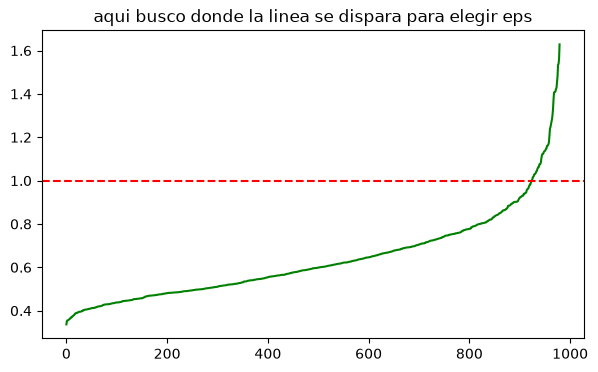

In [10]:
# busco un buen valor de eps mirando la distancia a los vecinos
vecinos = NearestNeighbors(n_neighbors=8)
vecinos.fit(X_pca)
distancias, _ = vecinos.kneighbors(X_pca)
distancias_ordenadas = np.sort(distancias[:, -1])

plt.figure(figsize=(7,4))
plt.plot(distancias_ordenadas, color="green")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("aqui busco donde la linea se dispara para elegir eps")
plt.show()


In [11]:
# agrupo con DBSCAN usando el eps que encontre
dbscan = DBSCAN(eps=1.0, min_samples=8)
df2["grupo_dbscan"] = dbscan.fit_predict(X_pca)

n_grupos = len(set(df2["grupo_dbscan"])) - (1 if -1 in df2["grupo_dbscan"].values else 0)
ruido = (df2["grupo_dbscan"] == -1).sum()
print("encontro", n_grupos, "grupos y dejó", ruido, "canciones sueltas (raras)")
print(df2["grupo_dbscan"].value_counts())


encontro 4 grupos y dejó 13 canciones sueltas (raras)
grupo_dbscan
 1    418
 0    207
 3    199
 2    143
-1     13
Name: count, dtype: int64


Como en este caso yo si sabia que genero le puse a cada cancion inventada (solo para comprobar, el programa no lo vio), puedo revisar si los grupos que salieron se parecen a los generos reales.


In [12]:
if "genero" in df2.columns:
    print("que tan parecido quedo kmeans al genero real:", round(adjusted_rand_score(df2["genero"], df2["grupo_kmeans"]), 3))
    print("que tan parecido quedo dbscan al genero real:", round(adjusted_rand_score(df2["genero"], df2["grupo_dbscan"]), 3))

    print("\ncomparacion kmeans:")
    display(pd.crosstab(df2["genero"], df2["grupo_kmeans"]))

    print("\ncomparacion dbscan (-1 = rara):")
    display(pd.crosstab(df2["genero"], df2["grupo_dbscan"]))


que tan parecido quedo kmeans al genero real: 0.953
que tan parecido quedo dbscan al genero real: 0.745

comparacion kmeans:


grupo_kmeans,0,1,2,3,4
genero,,,,,
acustico,0,0,200,0,0
clasica,0,150,0,0,0
electronica,212,0,0,0,8
rap,0,0,0,210,0
rock,10,0,0,0,190



comparacion dbscan (-1 = rara):


grupo_dbscan,-1,0,1,2,3
genero,,,,,
acustico,1,0,0,0,199
clasica,7,0,0,143,0
electronica,0,0,220,0,0
rap,3,207,0,0,0
rock,2,0,198,0,0


kmeans casi adivinó los 5 generos por si solo. dbscan en cambio metió la musica electronica y el rock en un mismo grupo, porque suenan parecido en energia y volumen. no es un error, solo muestra que esos dos generos se parecen mucho en como suenan.


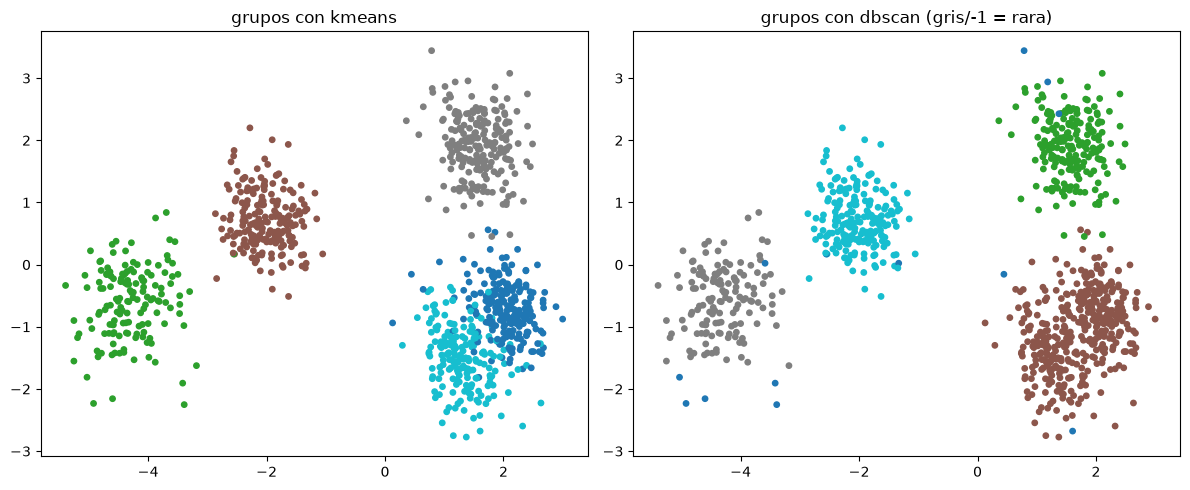

In [13]:
# dibujo las canciones coloreadas segun el grupo que le toco
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(df2["pc1"], df2["pc2"], c=df2["grupo_kmeans"], cmap="tab10", s=15)
axes[0].set_title("grupos con kmeans")

axes[1].scatter(df2["pc1"], df2["pc2"], c=df2["grupo_dbscan"], cmap="tab10", s=15)
axes[1].set_title("grupos con dbscan (gris/-1 = rara)")

plt.tight_layout()
plt.show()


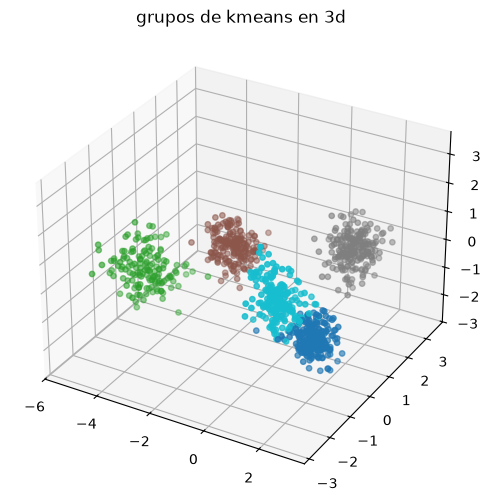

In [14]:
# lo mismo pero en 3d para verlo mejor
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df2["pc1"], df2["pc2"], df2["pc3"], c=df2["grupo_kmeans"], cmap="tab10", s=15)
ax.set_title("grupos de kmeans en 3d")
plt.show()


Aqui reviso, en vez de los 5 numeros resumidos de PCA, como se ve cada grupo con sus caracteristicas originales. Asi puedo entender que tipo de musica es cada grupo.


In [15]:
# promedio de cada caracteristica por grupo
perfil = df2.groupby("grupo_kmeans")[columnas].mean()
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
perfil_norm


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
grupo_kmeans,,,,,,,,,,
0,1.000000,1.000000,1.000000,0.118891,0.000000,0.367242,0.405867,1.000000,1.000000,0.187472
1,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.124632,0.000000,0.000000,1.000000
2,0.326396,0.133367,0.445301,0.003765,0.906580,0.019774,0.000000,0.341872,0.125393,0.444908
3,0.991633,0.646562,0.843265,1.000000,0.039475,0.000000,0.278786,0.805752,0.312917,0.000000
4,0.505735,0.943644,0.947685,0.044953,0.028377,0.109362,1.000000,0.875137,0.831382,0.596982


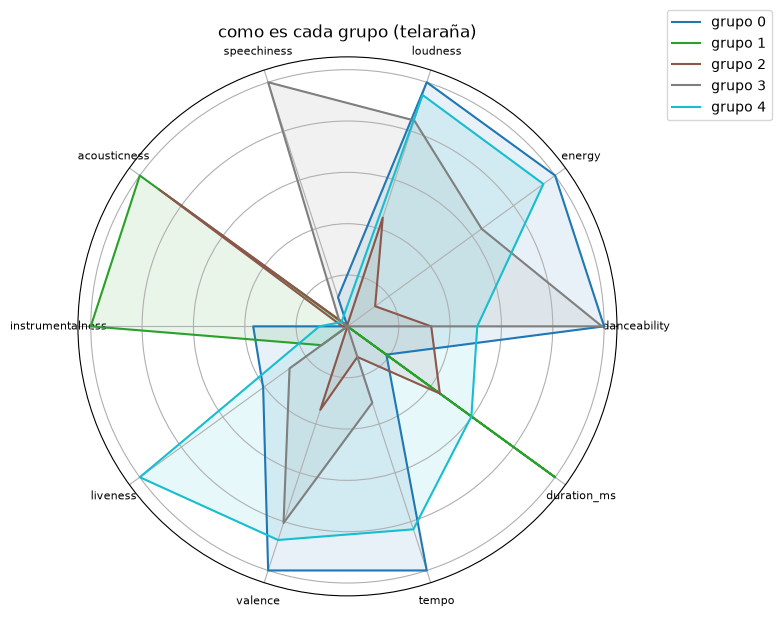

In [16]:
# dibujo una especie de telaraña para comparar los grupos
categorias = columnas
angulos = np.linspace(0, 2*np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
colores = cm.tab10(np.linspace(0,1,k_final))

for i in range(k_final):
    valores = perfil_norm.loc[i].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, color=colores[i], label="grupo " + str(i))
    ax.fill(angulos, valores, color=colores[i], alpha=0.1)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=8)
ax.set_yticklabels([])
plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
plt.title("como es cada grupo (telaraña)")
plt.show()


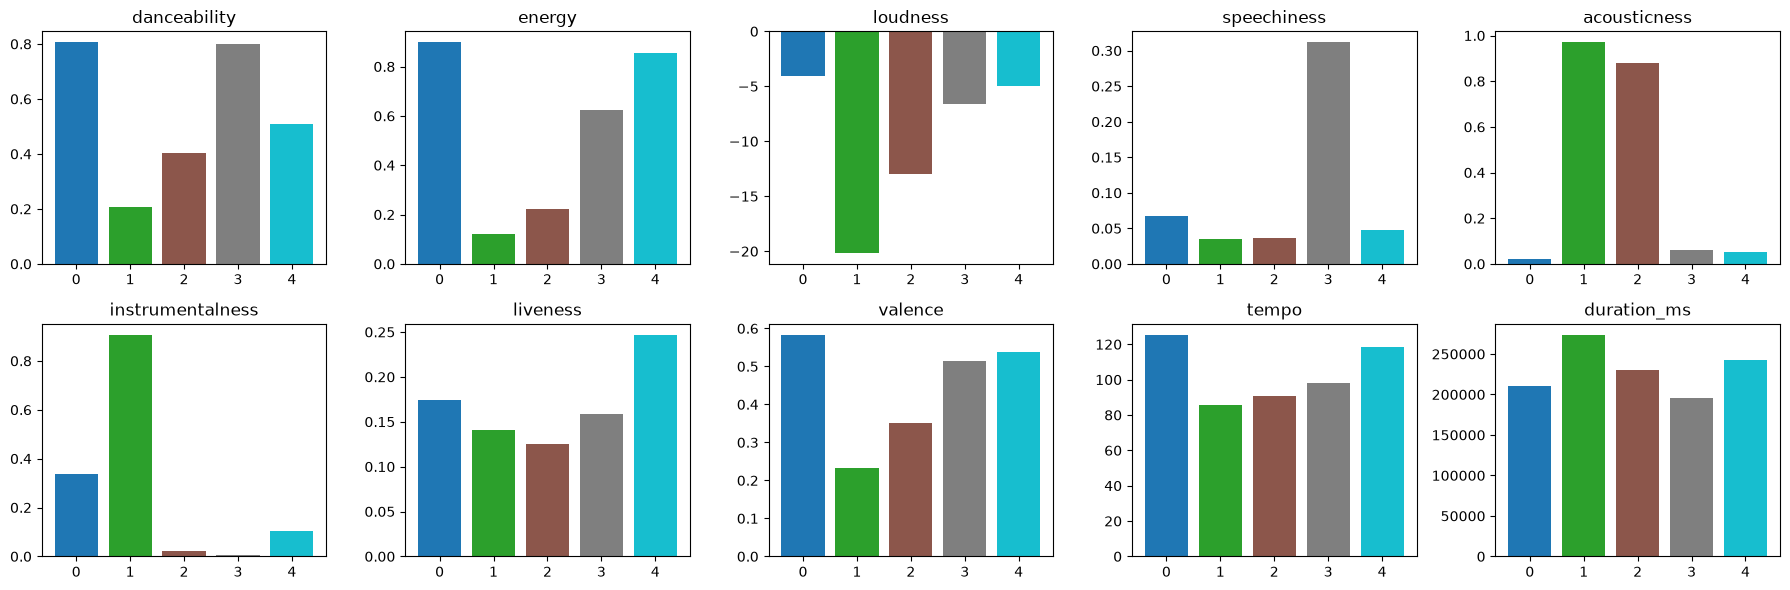

In [17]:
# ahora en barras, mas facil de leer
fig, axes = plt.subplots(2, 5, figsize=(18,6))
axes = axes.flatten()
for i, c in enumerate(columnas):
    axes[i].bar(perfil.index.astype(str), perfil[c], color=colores)
    axes[i].set_title(c)
plt.tight_layout()
plt.show()


Con todo esto, así entendí cada grupo (mirando los numeros y comparando con el genero que yo ya sabia):

- **grupo con mucha energia y muy bailable, casi nada acustico** -> se parece a musica electronica. serviria para playlist de fiesta o de gym.
- **grupo tranquilo, muy acustico, poco fuerte** -> se parece a baladas o musica acustica. serviria para playlist de relajarse o estudiar.
- **grupo con mucho "speechiness" (o sea mucha voz hablada)** -> se parece a rap. serviria para playlist urbana.
- **grupo muy acustico e instrumental, sin casi nada de energia, canciones largas** -> se parece a musica clasica. serviria para concentrarse o dormir.
- **grupo con harta energia pero menos electronico, mas "en vivo"** -> se parece a rock. serviria para playlist de viaje o ejercicio con guitarras.

Esto podria servirle a una app de musica para armar listas automaticas, o para recomendar canciones parecidas cuando no se sabe nada de un usuario nuevo (le preguntas cual "vibra" prefiere y le armas la lista con ese grupo).


**en resumen:** agarré canciones, les quité la escala rara de los numeros, resumí la info con PCA, y dejé que dos metodos (kmeans y dbscan) las agruparan solos. kmeans separó bien 5 tipos de musica, y dbscan mostró que dos de esos tipos (electronica y rock) suenan bastante parecido. con esto se podrian armar listas de reproduccion automaticas.
